<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

════════════════════════════════════════════════════════════════════════════════════════════════════
Chem006: Dipole Alignment and Field Response
════════════════════════════════════════════════════════════════════════════════════════════════════
Molecule | Dipole (D) | Torque (U) | Angle (U)  | Energy (U) | Torque (G) | Angle (G)  | Energy (G)
----------------------------------------------------------------------------------------------------
H2O      | 1.85       | 1.85       | 90.0       | -0.00      | 1.85       | 45.0       | -1.85     
CO2      | 0.00       | 0.00       | 0.0        | -0.00      | 0.00       | 0.0        | -0.00     
NH3      | 1.47       | 0.74       | 45.0       | -0.74      | 0.00       | 0.0        | -1.47     
CH4      | 0.00       | 0.00       | 0.0        | -0.00      | 0.00       | 0.0        | -0.00     
HF       | 1.83       | -1.83      | 90.0       | -0.00      | -1.83      | 135.0      | 1.83      


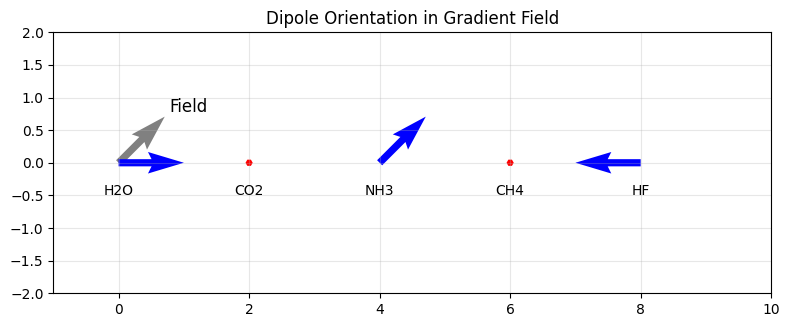

In [2]:
# Chem006: Dipole Alignment and Field Response in External Entropic Fields

import numpy as np
import matplotlib.pyplot as plt

# Define molecules with dipole moment (Debye) and orientation vectors
molecules = {
    "H2O":  {"dipole": 1.85, "orientation": np.array([1, 0])},
    "CO2":  {"dipole": 0.00, "orientation": np.array([1, 0])},
    "NH3":  {"dipole": 1.47, "orientation": np.array([0.5, 0.5])},
    "CH4":  {"dipole": 0.00, "orientation": np.array([0, 1])},
    "HF":   {"dipole": 1.83, "orientation": np.array([-1, 0])},
}

# External entropic fields
uniform_field = np.array([0, 1])     # vertical field
gradient_field = np.array([1, 1])    # diagonal field

# Function to compute torque, angle, and energy
def compute_response(mol, field):
    dipole_vector = mol["dipole"] * mol["orientation"]

    # Pad to 3D for cross product
    dipole_3d = np.array([dipole_vector[0], dipole_vector[1], 0])
    field_3d = np.array([field[0], field[1], 0])

    # Torque = z-component of μ × E
    torque = np.cross(dipole_3d, field_3d)[2]

    # Alignment angle (degrees between dipole and field)
    dot = np.dot(dipole_vector, field)
    norm_prod = np.linalg.norm(dipole_vector) * np.linalg.norm(field)
    angle_rad = np.arccos(dot / norm_prod) if norm_prod != 0 else 0
    angle_deg = np.degrees(angle_rad)

    # Energy change = –μ · E
    energy = -dot

    return round(torque, 2), round(angle_deg, 1), round(energy, 2)

# Run simulation
results = []
for name, mol in molecules.items():
    t_u, a_u, e_u = compute_response(mol, uniform_field)
    t_g, a_g, e_g = compute_response(mol, gradient_field)
    results.append({
        "Molecule": name,
        "Dipole (D)": mol["dipole"],
        "Torque (Uniform)": t_u,
        "Angle (Uniform)": a_u,
        "Energy (Uniform)": e_u,
        "Torque (Gradient)": t_g,
        "Angle (Gradient)": a_g,
        "Energy (Gradient)": e_g
    })

# Display results
print("═" * 100)
print("Chem006: Dipole Alignment and Field Response")
print("═" * 100)
print(f"{'Molecule':<8} | {'Dipole (D)':<10} | {'Torque (U)':<10} | {'Angle (U)':<10} | {'Energy (U)':<10} | "
      f"{'Torque (G)':<10} | {'Angle (G)':<10} | {'Energy (G)':<10}")
print("-" * 100)
for r in results:
    print(f"{r['Molecule']:<8} | {r['Dipole (D)']:<10.2f} | {r['Torque (Uniform)']:<10.2f} | {r['Angle (Uniform)']:<10.1f} | {r['Energy (Uniform)']:<10.2f} | "
          f"{r['Torque (Gradient)']:<10.2f} | {r['Angle (Gradient)']:<10.1f} | {r['Energy (Gradient)']:<10.2f}")

# Visualization: Dipole alignment in gradient field
fig, ax = plt.subplots(figsize=(8, 8))
field_vec = gradient_field / np.linalg.norm(gradient_field)
ax.quiver(0, 0, field_vec[0], field_vec[1], angles='xy', scale_units='xy', scale=1, color='gray', width=0.01)
ax.text(field_vec[0]*1.1, field_vec[1]*1.1, "Field", fontsize=12)

for i, (name, mol) in enumerate(molecules.items()):
    dipole_vec = mol["dipole"] * mol["orientation"]
    dipole_unit = dipole_vec / np.linalg.norm(dipole_vec) if np.linalg.norm(dipole_vec) != 0 else np.array([0, 0])
    ax.quiver(i*2, 0, dipole_unit[0], dipole_unit[1], angles='xy', scale_units='xy', scale=1,
              color='blue' if mol["dipole"] > 0 else 'red', width=0.01)
    ax.text(i*2, -0.5, name, ha='center', fontsize=10)

ax.set_xlim(-1, 10)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_title("Dipole Orientation in Gradient Field")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
